In [3]:
import pandas as pd

red_url = "https://raw.github.com/PinkWink/ML_tutorial/master/dataset/winequality-red.csv"
white_url = "https://raw.github.com/PinkWink/ML_tutorial/master/dataset/winequality-white.csv"

red_wine = pd.read_csv(red_url, sep=';')
white_wine = pd.read_csv(white_url, sep=';')

In [6]:
red_wine["color"] = 1
white_wine["color"] = 1

wine = pd.concat([red_wine, white_wine])
wine["taste"] = [1. if grade > 5 else 0. for grade in wine["quality"]]

X = wine.drop(["taste", "quality"], axis=1)
y = wine["taste"]

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

wine_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
wine_tree.fit(X_train, y_train)

y_pred_tr = wine_tree.predict(X_train)
y_pred_test = wine_tree.predict(X_test)

print("Train Acc: ", accuracy_score(y_train, y_pred_tr))
print("Test Acc: ", accuracy_score(y_test, y_pred_test))

Train Acc:  0.7383105637868
Test Acc:  0.7084615384615385


In [16]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve)

print("Accurary: ", accuracy_score(y_test, y_pred_test))
print("Recall: ", accuracy_score(y_test, y_pred_test))
print("Precision: ", accuracy_score(y_test, y_pred_test))
print("AUC Score: ", accuracy_score(y_test, y_pred_test))
print("F1 Score: ", accuracy_score(y_test, y_pred_test))

Accurary:  0.7084615384615385
Recall:  0.7084615384615385
Precision:  0.7084615384615385
AUC Score:  0.7084615384615385
F1 Score:  0.7084615384615385


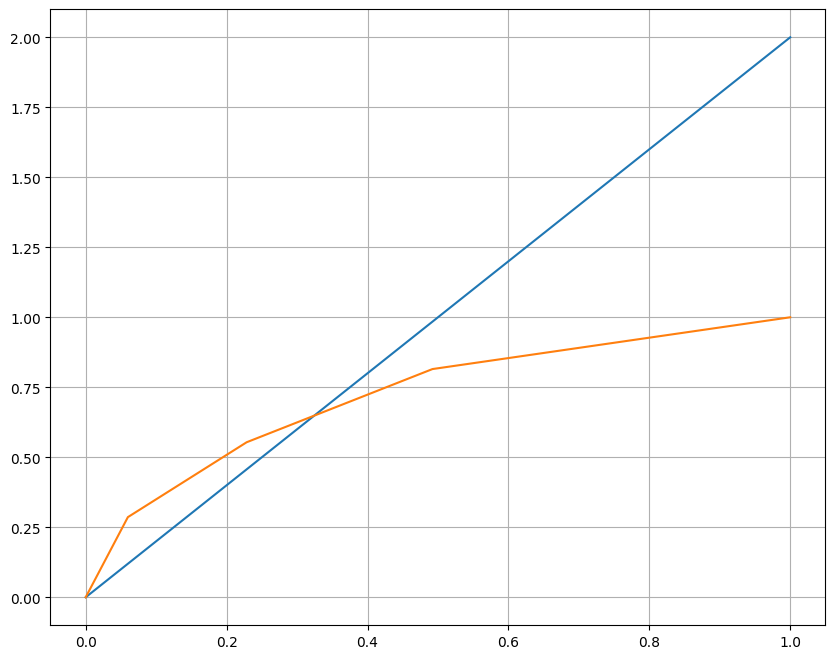

In [17]:
import matplotlib.pyplot as plt

pred_proba = wine_tree.predict_proba(X_test)[:, 1]
fpr, tpr, thresholes = roc_curve(y_test, pred_proba)

plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 2])
plt.plot(fpr, tpr)
plt.grid()
plt.show()